In [2]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, MobileNetV2
import os, tarfile, time, re

tf.random.set_seed(42)
np.random.seed(42)

IMG_SIZE = 224
BATCH_SIZE = 32

DATA_DIR = "/content/oxford_pets"
os.makedirs(DATA_DIR, exist_ok=True)
images_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
images_path = tf.keras.utils.get_file("images.tar.gz", images_url, cache_dir=DATA_DIR, extract=False)

if not os.path.exists(os.path.join(DATA_DIR, "images")):
    print("Extracting images...")
    with tarfile.open(images_path) as tar:
        tar.extractall(path=DATA_DIR)

img_dir = os.path.join(DATA_DIR, "images")
all_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
print("Total images found:", len(all_files))
def get_breed(fname):
    return re.sub(r'_\d+\.jpg$', '', fname)

breeds = sorted(set(get_breed(f) for f in all_files))
class_names = breeds
NUM_CLASSES = len(class_names)
breed_to_idx = {b: i for i, b in enumerate(breeds)}
print("Number of classes:", NUM_CLASSES)

labels = np.array([breed_to_idx[get_breed(f)] for f in all_files])
filepaths = np.array([os.path.join(img_dir, f) for f in all_files])
rng = np.random.default_rng(42)
perm = rng.permutation(len(filepaths))
filepaths, labels = filepaths[perm], labels[perm]

n = len(filepaths)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_files, train_labels = filepaths[:n_train], labels[:n_train]
val_files, val_labels     = filepaths[n_train:n_train+n_val], labels[n_train:n_train+n_val]
test_files, test_labels   = filepaths[n_train+n_val:], labels[n_train+n_val:]

print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, label

def make_ds(files, labels, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(1000, seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_files, train_labels, shuffle=True)
val_ds   = make_ds(val_files, val_labels)
test_ds  = make_ds(test_files, test_labels)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:  ", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches: ", tf.data.experimental.cardinality(test_ds).numpy())

def get_mobilenet_base(trainable=False, unfreeze_from=None):
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                        include_top=False,
                        weights='imagenet',
                        pooling='avg')
    base.trainable = trainable
    if trainable and unfreeze_from is not None:
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False
    return base

Total images found: 7390
Number of classes: 37
Train: 5173, Val: 1108, Test: 1109
Train batches: 162
Val batches:   35
Test batches:  35


Task 2 — Regularization & Overfitting (Plots 3 & 4)


--- Training with None regularization ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 64s 268ms/step - accuracy: 0.7819 - loss: 0.8152 - val_accuracy: 0.8782 - val_loss: 0.3930
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9333 - loss: 0.2108 - val_accuracy: 0.9134 - val_loss: 0.2881
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.9654 - loss: 0.1176 - val_accuracy: 0.8971 - val_loss: 0.3353
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.9768 - loss: 0.0807 - val_accuracy: 0.9061 - val_loss: 0.2939
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.9909 - loss: 0.0446 - val_accuracy: 0.9179 - val_loss: 0.2845

--- Training with L2 regularization ---
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 37s 172ms/step - accuracy: 0.7876 - loss: 2.3743 - val_accuracy: 0.8944 - val_loss: 1.2995
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.9163 - loss: 0.9409 - va

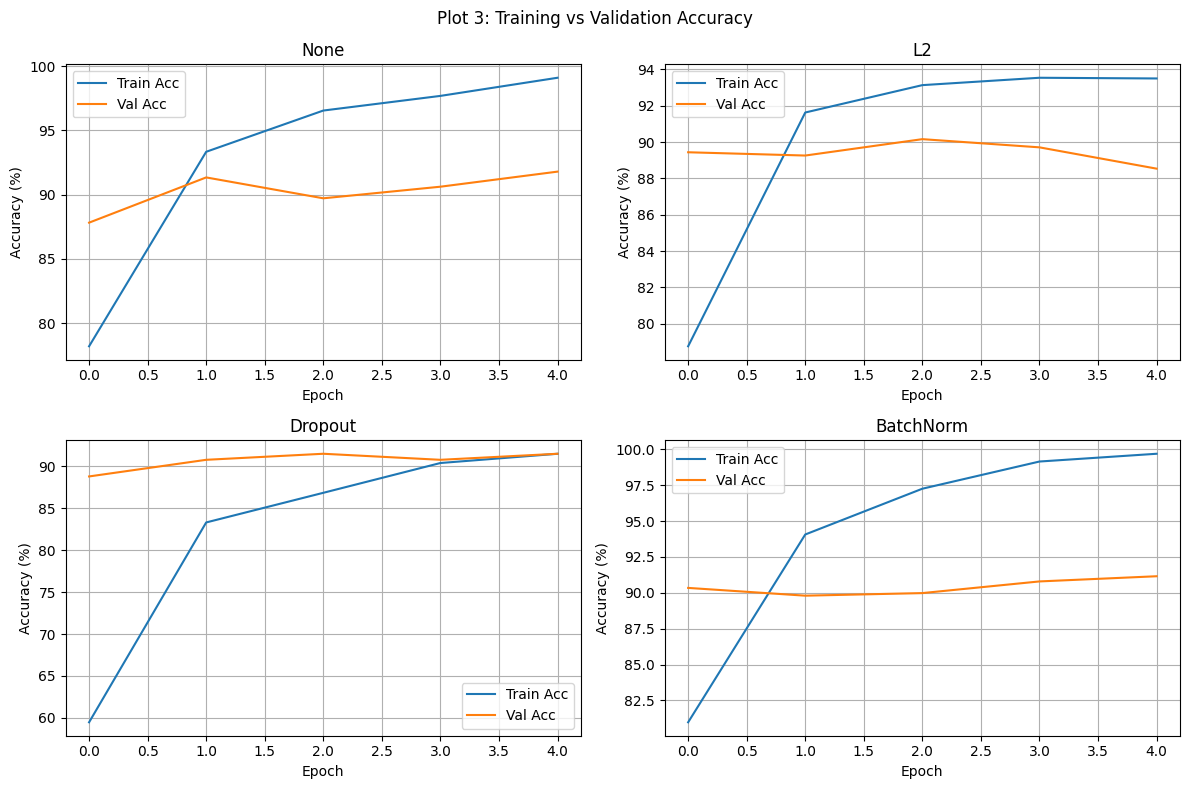

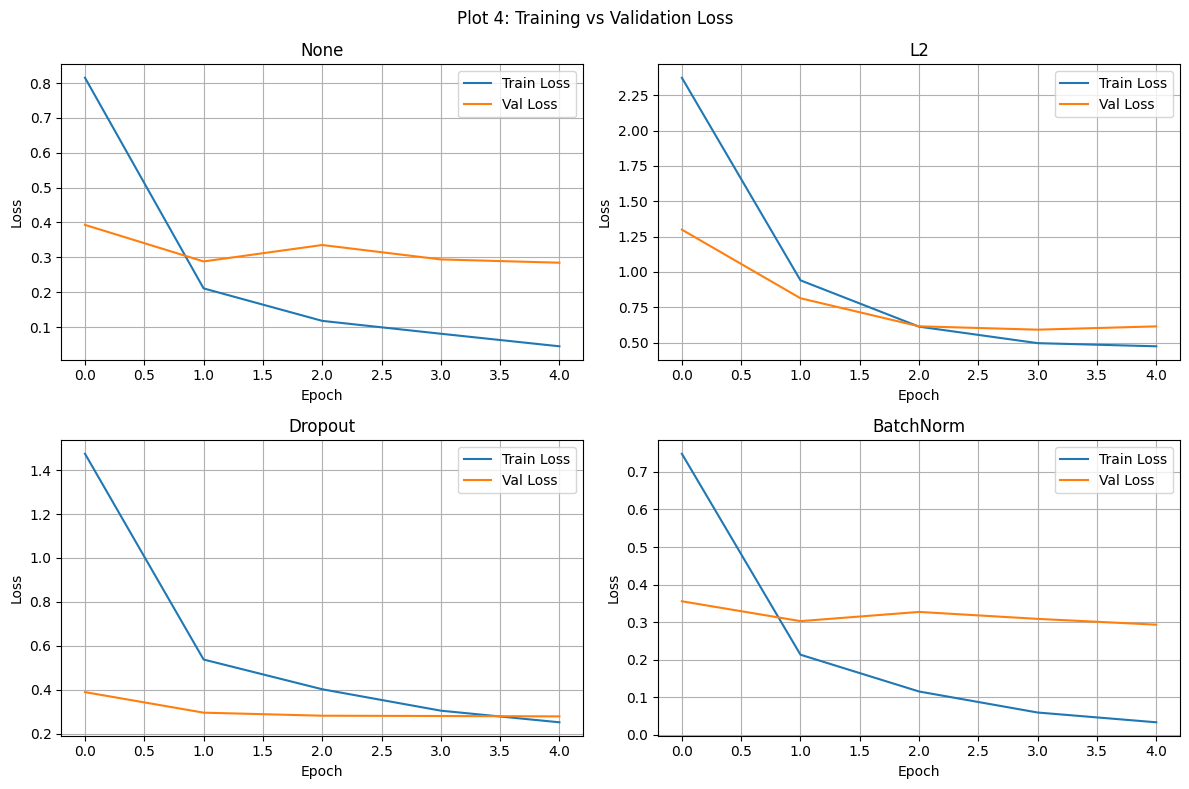

In [2]:
# TASK 2: REGULARIZATION - None, L2, Dropout, BatchNorm
def build_model_reg(reg_type):
    base = get_mobilenet_base(trainable=False)
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)

    if reg_type == "None":
        x = layers.Dense(128, activation='relu')(x)
    elif reg_type == "L2":
        x = layers.Dense(128, activation='relu',
                          kernel_regularizer=regularizers.l2(0.01))(x)
    elif reg_type == "Dropout":
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
    elif reg_type == "BatchNorm":
        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

reg_types = ["None", "L2", "Dropout", "BatchNorm"]
EPOCHS = 5
reg_histories = {}

for rtype in reg_types:
    print(f"\n--- Training with {rtype} regularization ---")
    model = build_model_reg(rtype)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
    reg_histories[rtype] = history.history

# Plot 3: Training and Validation Accuracy vs Epoch (per regularization type)
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for ax, rtype in zip(axes.flat, reg_types):
    hist = reg_histories[rtype]
    ax.plot([a*100 for a in hist['accuracy']], label='Train Acc')
    ax.plot([a*100 for a in hist['val_accuracy']], label='Val Acc')
    ax.set_title(f'{rtype}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(); ax.grid(True)
plt.suptitle('Plot 3: Training vs Validation Accuracy')
plt.tight_layout(); plt.show()

# Plot 4: Training and Validation Loss vs Epoch
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for ax, rtype in zip(axes.flat, reg_types):
    hist = reg_histories[rtype]
    ax.plot(hist['loss'], label='Train Loss')
    ax.plot(hist['val_loss'], label='Val Loss')
    ax.set_title(f'{rtype}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True)
plt.suptitle('Plot 4: Training vs Validation Loss')
plt.tight_layout(); plt.show()

Total samples for CV: 6281
Subsampled to: 2000

=== Config: C1_baseline ===
  Fold 1: Val Accuracy = 88.75%
  Fold 2: Val Accuracy = 86.50%
  Fold 3: Val Accuracy = 90.75%
  Fold 4: Val Accuracy = 87.50%
  Fold 5: Val Accuracy = 88.00%

=== Config: C2_high_dropout ===
  Fold 1: Val Accuracy = 89.50%
  Fold 2: Val Accuracy = 87.25%
  Fold 3: Val Accuracy = 90.25%
  Fold 4: Val Accuracy = 90.75%
  Fold 5: Val Accuracy = 89.25%

=== Config: C3_low_lr ===
  Fold 1: Val Accuracy = 76.75%
  Fold 2: Val Accuracy = 73.25%
  Fold 3: Val Accuracy = 82.25%
  Fold 4: Val Accuracy = 77.75%
  Fold 5: Val Accuracy = 81.25%

=== Config: C4_rmsprop ===
  Fold 1: Val Accuracy = 88.00%
  Fold 2: Val Accuracy = 86.00%
  Fold 3: Val Accuracy = 89.75%
  Fold 4: Val Accuracy = 87.50%
  Fold 5: Val Accuracy = 87.25%
  Configuration    F1    F2    F3    F4    F5  Mean   SD
    C1_baseline 88.75 86.50 90.75 87.50 88.00 88.30 1.43
C2_high_dropout 89.50 87.25 90.25 90.75 89.25 89.40 1.20
      C3_low_lr 76.75 73.

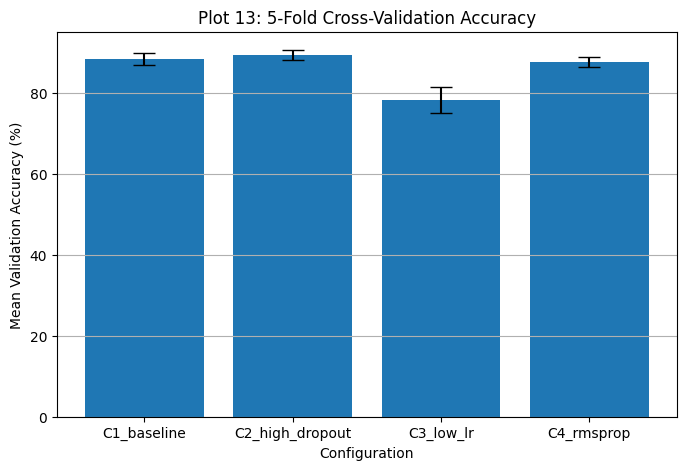

In [3]:
# TASK 7 (MEMORY-SAFE): 5-FOLD CROSS-VALIDATION — no full dataset in RAM
from sklearn.model_selection import KFold
import pandas as pd

# Combine train + val FILE PATHS for CV (test set stays untouched)
# This is tiny — just strings, no images loaded yet
cv_files = np.concatenate([train_files, val_files])
cv_labels = np.concatenate([train_labels, val_labels])
print("Total samples for CV:", len(cv_files))

# OPTIONAL: subsample if you want faster/lighter runs — recommended on CPU
subset_size = 2000  # reduce further (e.g. 1000) if still crashing
if len(cv_files) > subset_size:
    idx = np.random.default_rng(42).choice(len(cv_files), subset_size, replace=False)
    cv_files, cv_labels = cv_files[idx], cv_labels[idx]
    print("Subsampled to:", len(cv_files))

CV_BATCH_SIZE = 32

def make_ds_from_arrays(files, labels, batch_size=CV_BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(len(files), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

configs = {
    "C1_baseline": {"dropout": 0.3, "lr": 0.001, "optimizer": "adam"},
    "C2_high_dropout": {"dropout": 0.5, "lr": 0.001, "optimizer": "adam"},
    "C3_low_lr": {"dropout": 0.3, "lr": 0.0001, "optimizer": "adam"},
    "C4_rmsprop": {"dropout": 0.3, "lr": 0.001, "optimizer": "rmsprop"},
}

def build_cv_model(cfg):
    base = get_mobilenet_base(trainable=False)
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(cfg["dropout"])(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    opt = optimizers.Adam(learning_rate=cfg["lr"]) if cfg["optimizer"]=="adam" \
          else optimizers.RMSprop(learning_rate=cfg["lr"])
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
EPOCHS_CV = 5

for cfg_name, cfg in configs.items():
    fold_accs = []
    print(f"\n=== Config: {cfg_name} ===")
    for fold, (train_idx, val_idx) in enumerate(kf.split(cv_files)):
        # Only file paths are indexed here — no big arrays
        fold_train_files = cv_files[train_idx]
        fold_train_labels = cv_labels[train_idx]
        fold_val_files = cv_files[val_idx]
        fold_val_labels = cv_labels[val_idx]

        fold_train_ds = make_ds_from_arrays(fold_train_files, fold_train_labels, shuffle=True)
        fold_val_ds = make_ds_from_arrays(fold_val_files, fold_val_labels)

        model = build_cv_model(cfg)
        model.fit(fold_train_ds, validation_data=fold_val_ds,
                  epochs=EPOCHS_CV, verbose=0)
        val_loss, val_acc = model.evaluate(fold_val_ds, verbose=0)
        fold_accs.append(val_acc * 100)
        print(f"  Fold {fold+1}: Val Accuracy = {val_acc*100:.2f}%")

        # Free memory between folds
        del model, fold_train_ds, fold_val_ds
        tf.keras.backend.clear_session()
        import gc; gc.collect()

    cv_results[cfg_name] = fold_accs

# Results table: F1-F5, Mean ± SD
cv_table = []
for cfg_name, accs in cv_results.items():
    row = {"Configuration": cfg_name}
    for i, acc in enumerate(accs):
        row[f"F{i+1}"] = round(acc, 2)
    row["Mean"] = round(np.mean(accs), 2)
    row["SD"] = round(np.std(accs), 2)
    cv_table.append(row)

df_cv = pd.DataFrame(cv_table)
print(df_cv.to_string(index=False))

# Plot 13: 5-Fold CV Accuracy with error bars
means = [np.mean(v) for v in cv_results.values()]
sds = [np.std(v) for v in cv_results.values()]
names = list(cv_results.keys())

plt.figure(figsize=(8,5))
plt.bar(names, means, yerr=sds, capsize=8)
plt.xlabel('Configuration'); plt.ylabel('Mean Validation Accuracy (%)')
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy')
plt.grid(True, axis='y')
plt.show()

Best configuration selected: C2_high_dropout
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.4135 - loss: 2.2573
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.7530 - loss: 0.8332
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.8420 - loss: 0.5436
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.8785 - loss: 0.3763
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.9055 - loss: 0.3097
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9335 - loss: 0.2363
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.9375 - loss: 0.2121
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9455 - loss: 0.1852
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9590 - loss: 0.1499
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9610 - loss: 0.1341
Test Accuracy: 89.81%
                                0
Mean CV Accuracy            89.40
CV Standard 

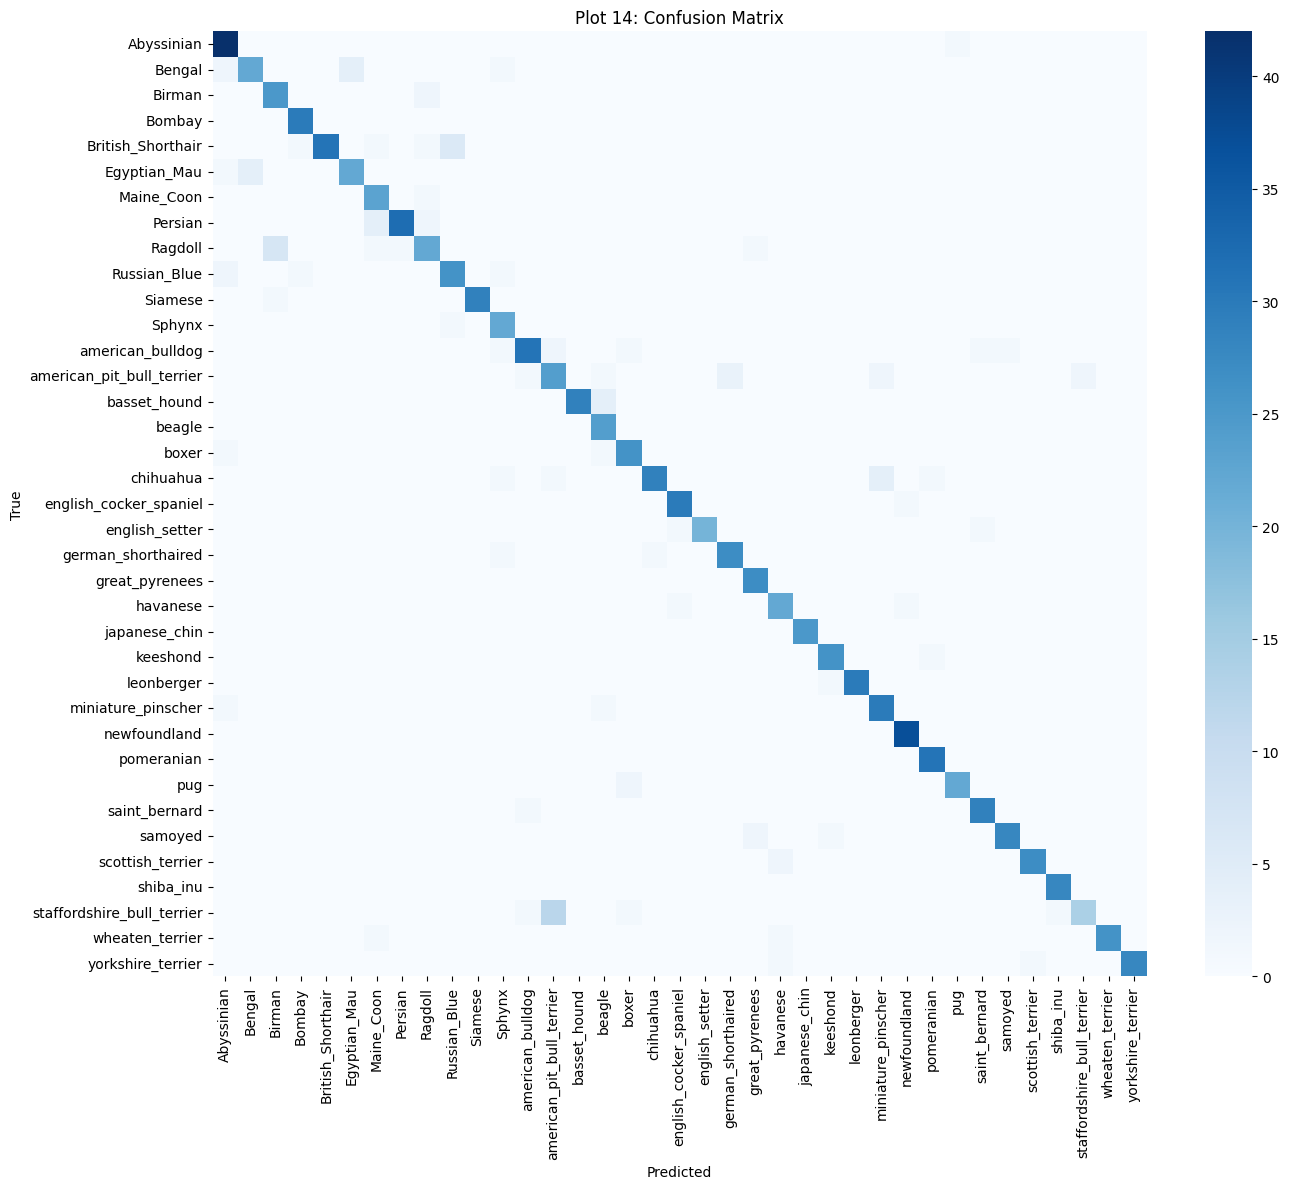

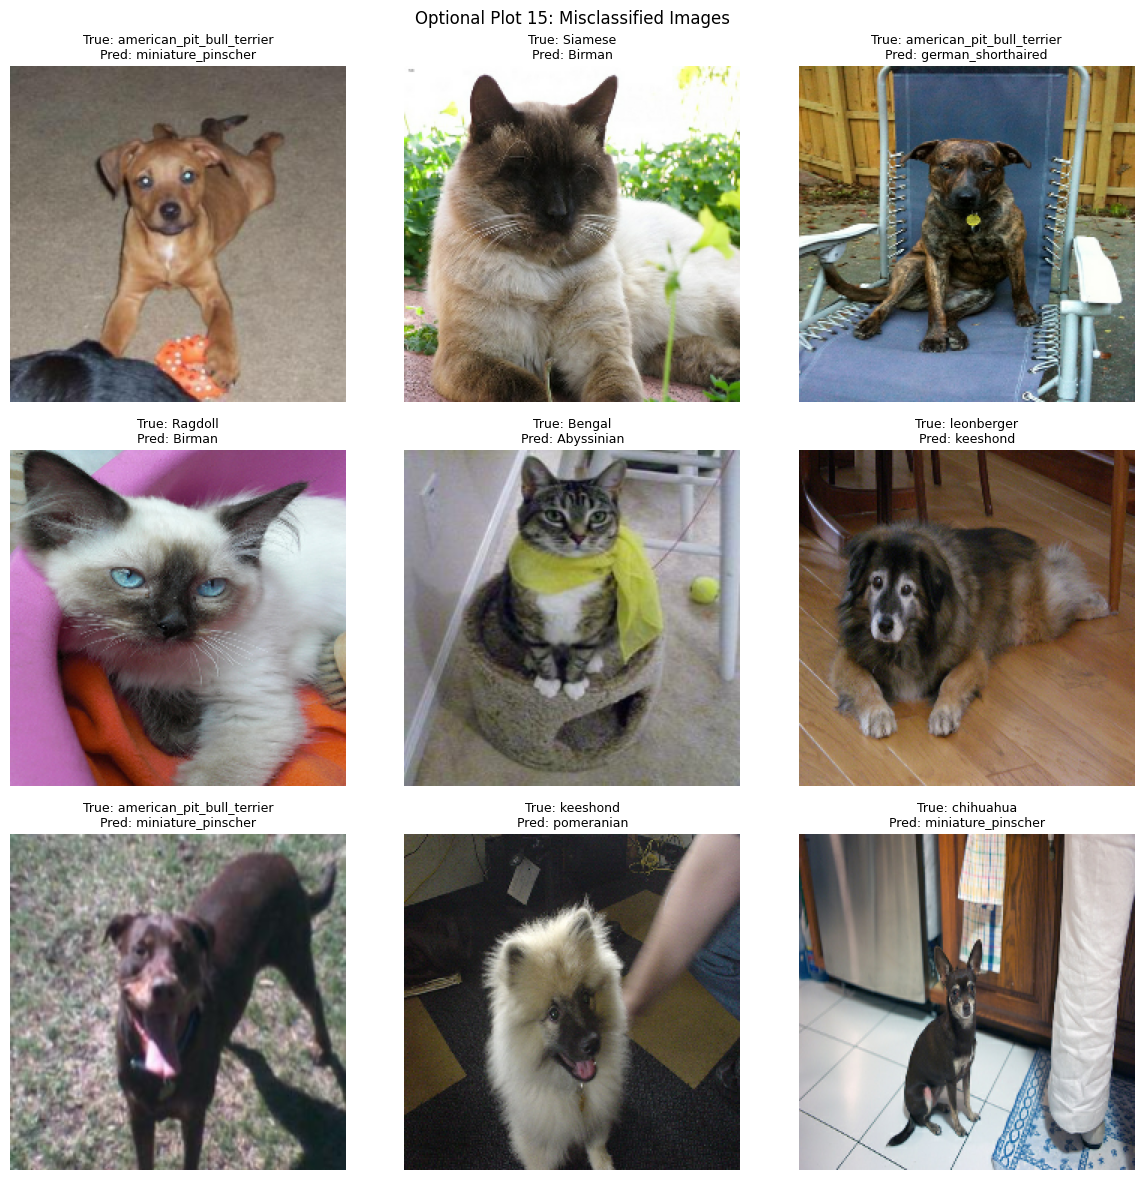

0

In [4]:
# TASK 8 (MEMORY-SAFE): FINAL MODEL EVALUATION — no full dataset in RAM
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import gc

# Select best config from Task 7 results
best_config_name = max(cv_results, key=lambda k: np.mean(cv_results[k]))
print("Best configuration selected:", best_config_name)
best_cfg = configs[best_config_name]

# Build streaming datasets for full CV data (train+val) and test set
# Reuses cv_files/cv_labels from Task 7 (already subsampled if you subsampled there)
final_train_ds = make_ds_from_arrays(cv_files, cv_labels, shuffle=True)
final_test_ds  = make_ds_from_arrays(test_files, test_labels, shuffle=False)

# Retrain final model on full CV data (test set stays untouched until now)
final_model = build_cv_model(best_cfg)
start = time.time()
history_final = final_model.fit(final_train_ds, epochs=10, verbose=1)
train_time = time.time() - start

# Evaluate on test set (streamed, not loaded into one array)
test_loss, test_acc = final_model.evaluate(final_test_ds, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Get predictions batch-by-batch (avoids materializing all test images at once)
y_pred_list = []
y_true_list = []
for batch_imgs, batch_labels in final_test_ds:
    preds = final_model.predict(batch_imgs, verbose=0)
    y_pred_list.append(np.argmax(preds, axis=1))
    y_true_list.append(batch_labels.numpy())

y_pred = np.concatenate(y_pred_list)
y_test = np.concatenate(y_true_list)

precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
num_params = final_model.count_params()

metrics_table = pd.DataFrame([{
    "Mean CV Accuracy": round(np.mean(cv_results[best_config_name]), 2),
    "CV Standard Deviation": round(np.std(cv_results[best_config_name]), 2),
    "Test Accuracy": round(test_acc*100, 2),
    "Precision": round(precision*100, 2),
    "Recall": round(recall*100, 2),
    "F1-score": round(f1*100, 2),
    "Training Time (s)": round(train_time, 1),
    "Number of Parameters": num_params
}])
print(metrics_table.T)

# Plot 14: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Plot 14: Confusion Matrix')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# Optional Plot 15: Misclassified Images
# Re-fetch just the ~9 misclassified images individually (cheap) rather than keeping all test images around
misclassified_idx = np.where(y_pred != y_test)[0][:9]

# Build a flat array of test filepaths in the SAME order the dataset iterated them
# (tf.data with shuffle=False preserves order, so this lines up with y_test/y_pred)
test_files_ordered = test_files  # already unshuffled, matches final_test_ds order

plt.figure(figsize=(12,12))
for i, idx in enumerate(misclassified_idx):
    img, _ = load_and_preprocess(test_files_ordered[idx], test_labels[idx])
    img_display = (img.numpy() + 1) / 2.0  # de-normalize approx for display
    plt.subplot(3, 3, i+1)
    plt.imshow(np.clip(img_display, 0, 1))
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9)
    plt.axis('off')
plt.suptitle('Optional Plot 15: Misclassified Images')
plt.tight_layout(); plt.show()

# Cleanup
tf.keras.backend.clear_session()
gc.collect()